In [ ]:
# Imports to enable plotting functionality
import numpy as np
import matplotlib.pyplot as plt
import bz2
import pickle
import _pickle as cPickle
import os 

## Soma functions to enable loading of the pickle files

In [2]:
# Pickle a file and then compress it into a file with extension 
def compressed_pickle(title, data):
    with bz2.BZ2File(title + '.pbz2', 'w') as f: 
        cPickle.dump(data, f)

# Load any compressed pickle file
def decompress_pickle(file):
    data = bz2.BZ2File(file+'.pbz2', 'rb')
    data = cPickle.load(data)
    return data

def findData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        
    return currents,thresholds

def findInitData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []
    init_seg = []
    init_time = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        init_seg.append(data[2])
        init_time.append(data[3])
        
    return currents,thresholds,init_seg,init_time

def truncate_lists(X, Y, threshold):
    # Use list comprehension to filter out indices where Y >= threshold
    X_truncated = [x for x, y in zip(X, Y) if np.abs(y) >= threshold]
    Y_truncated = [y for y in Y if np.abs(y) >= threshold]
    return X_truncated, Y_truncated

def truncate_lists_init(X, Y, S, T, threshold):
    # Use list comprehension to filter out indices where Y >= threshold
    X_truncated = [x for x, y in zip(X, Y) if np.abs(y) >= threshold]
    S_truncated = [s for s, y in zip(S, Y) if np.abs(y) >= threshold]
    T_truncated = [t for t, y in zip(T, Y) if np.abs(y) >= threshold]
    Y_truncated = [y for y in Y if np.abs(y) >= threshold]
    
    return X_truncated, Y_truncated, S_truncated, T_truncated

In [3]:
primary_0,secondary_0 = findData([15,0,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/distal/')
primary_0_s, secondary_0_s = truncate_lists(primary_0, secondary_0, 0.026)

primary_10,secondary_10 = findData([15,10,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/distal/')
primary_10_s, secondary_10_s = truncate_lists(primary_10, secondary_10, 0.026)

primary_20,secondary_20 = findData([15,20,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/distal/')
primary_20_s, secondary_20_s = truncate_lists(primary_20, secondary_20, 0.026)

primary_30,secondary_30 = findData([15,30,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/distal/')
primary_30_s, secondary_30_s = truncate_lists(primary_30, secondary_30, 0.026)

primary_60,secondary_60 = findData([15,60,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/distal/')
primary_60_s, secondary_60_s = truncate_lists(primary_60, secondary_60, 0.026)

primary_70,secondary_70 = findData([15,70,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/distal/')
primary_70_s, secondary_70_s = truncate_lists(primary_70, secondary_70, 0.026)

primary_80,secondary_80 = findData([15,80,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/distal/')
primary_80_s, secondary_80_s = truncate_lists(primary_80, secondary_80, 0.026)

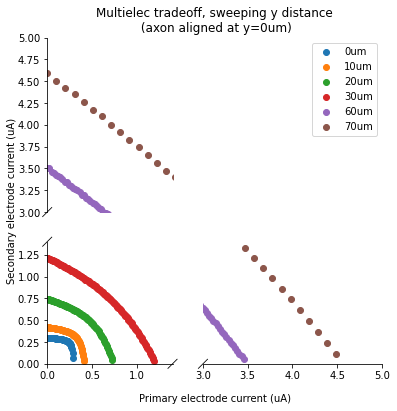

In [4]:
fig = plt.figure(figsize=(6,6))
bax = brokenaxes(xlims=((0, 1.4), (3, 5)), ylims=((0, 1.4), (3, 5)),hspace=.2,wspace=0.2)


bax.scatter(np.abs(primary_0_s),np.abs(secondary_0_s),label='0um')
bax.scatter(np.abs(primary_10_s),np.abs(secondary_10_s),label='10um')
bax.scatter(np.abs(primary_20_s),np.abs(secondary_20_s),label='20um')
bax.scatter(np.abs(primary_30_s),np.abs(secondary_30_s),label='30um')
bax.scatter(np.abs(primary_60_s),np.abs(secondary_60_s),label='60um')
bax.scatter(np.abs(primary_70_s),np.abs(secondary_70_s),label='70um')
# bax.scatter(np.abs(primary_80_s),np.abs(secondary_80_s),label='80um')

bax.set_xlabel('Primary electrode current (uA)')
bax.set_ylabel('Secondary electrode current (uA)')
bax.set_title('Multielec tradeoff, sweeping y distance\n (axon aligned at y=0um)')
bax.legend()


# bax.legend(['0um','10um','20um','30um'])

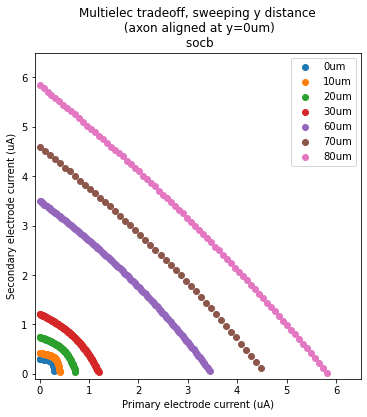

In [5]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

ax.scatter(np.abs(primary_0_s),np.abs(secondary_0_s))
ax.scatter(np.abs(primary_10_s),np.abs(secondary_10_s))
ax.scatter(np.abs(primary_20_s),np.abs(secondary_20_s))
ax.scatter(np.abs(primary_30_s),np.abs(secondary_30_s))
ax.scatter(np.abs(primary_60_s),np.abs(secondary_60_s))
ax.scatter(np.abs(primary_70_s),np.abs(secondary_70_s))
ax.scatter(np.abs(primary_80_s),np.abs(secondary_80_s))


ax.set_aspect('equal')
ax.set_xlabel('Primary electrode current (uA)')
ax.set_ylabel('Secondary electrode current (uA)')
ax.set_xlim(-0.1,6.5)
ax.set_ylim(-0.1,6.5)
ax.set_title('Multielec tradeoff, sweeping y distance\n (axon aligned at y=0um)\n socb')
plt.legend(['0um','10um','20um','30um','60um','70um','80um'])
# plt.legend(['0um','10um','20um','30um'])

## Now, let's see what things look like over the distal axon

In [158]:
primary_0,secondary_0 = findData([15,0,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/distal_v2/')
primary_0_s, secondary_0_s = truncate_lists(primary_0, secondary_0, 0.026)

primary_5,secondary_5 = findData([15,5,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/distal_v2/')
primary_5_s, secondary_5_s = truncate_lists(primary_5, secondary_5, 0.026)

primary_10,secondary_10 = findData([15,10,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/distal_v2/')
primary_10_s, secondary_10_s = truncate_lists(primary_10, secondary_10, 0.026)

primary_20,secondary_20 = findData([15,20,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/distal_v2/')
primary_20_s, secondary_20_s = truncate_lists(primary_20, secondary_20, 0.026)

primary_30,secondary_30 = findData([15,30,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/distal_v2/')
primary_30_s, secondary_30_s = truncate_lists(primary_30, secondary_30, 0.026)

primary_60,secondary_60 = findData([15,60,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/distal_v2/')
primary_60_s, secondary_60_s = truncate_lists(primary_60, secondary_60, 0.026)

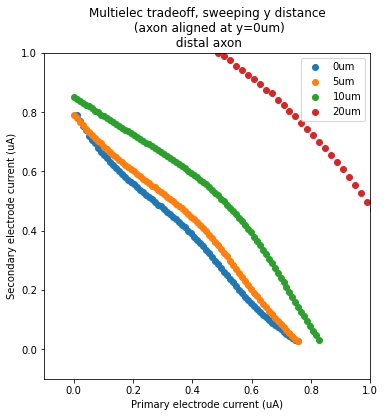

In [161]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

ax.scatter(np.abs(primary_0_s),np.abs(secondary_0_s))
ax.scatter(np.abs(primary_5_s),np.abs(secondary_5_s))
ax.scatter(np.abs(primary_10_s),np.abs(secondary_10_s))
ax.scatter(np.abs(primary_20_s),np.abs(secondary_20_s))
# ax.scatter(np.abs(primary_30_s),np.abs(secondary_30_s))
# ax.scatter(np.abs(primary_60_s),np.abs(secondary_60_s))


ax.set_aspect('equal')
ax.set_xlabel('Primary electrode current (uA)')
ax.set_ylabel('Secondary electrode current (uA)')
ax.set_xlim(-0.1,1)
ax.set_ylim(-0.1,1)
ax.set_title('Multielec tradeoff, sweeping y distance\n (axon aligned at y=0um)\n distal axon')
# plt.legend(['0um','5um','10um','20um','30um','60um'])
# plt.legend(['0um','5um','10um','20um','30um'])
plt.legend(['0um','5um','10um','20um'])


## Try out triphasic 

In [63]:
primary_0,secondary_0 = findData([-15,0,20],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/triphasic/allSites/socb/spikeInit/disk/')
primary_0_s, secondary_0_s = truncate_lists(primary_0, secondary_0, 0.026)

In [64]:
print(len(primary_0_s))

51


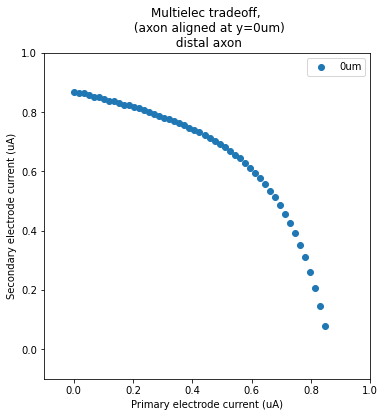

In [65]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

ax.scatter(np.abs(primary_0_s),np.abs(secondary_0_s))

ax.set_aspect('equal')
ax.set_xlabel('Primary electrode current (uA)')
ax.set_ylabel('Secondary electrode current (uA)')
ax.set_xlim(-0.1,1)
ax.set_ylim(-0.1,1)
ax.set_title('Multielec tradeoff, \n (axon aligned at y=0um)\n distal axon')

plt.legend(['0um','5um','10um','20um'])